# Tesla Deliveries Analysis and Machine Learning Pipeline

## Objective

Design and implement an end-to-end Machine Learning pipeline on Tesla sales and delivery data covering:

- Data preprocessing and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Model evaluation
- Cross-validation
- Hyperparameter tuning
- Time series forecasting

The primary objective is to analyze the factors influencing Tesla vehicle deliveries, build predictive regression models, evaluate their performance, and forecast future delivery trends using time-series techniques.


*Importing Libraries*

In [190]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Loading the dataset

Loading the Tesla deliveries datset into the notebook

In [191]:
df = pd.read_csv("Resources/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Overview of dataset

Basic overview of the data to understand its structure, type and overall features of data

In [192]:
shape = df.shape
print("Shape of the DataFrame:", shape)
columns = df.columns
print("Columns in the DataFrame:", columns.tolist())

Shape of the DataFrame: (2640, 12)
Columns in the DataFrame: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [193]:
print("Information about the DataFrame:")
df.info()

Information about the DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [194]:
print("Data types of each feature of the DataFrame:")
df.dtypes

Data types of each feature of the DataFrame:


Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

In [195]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Cleaning the data

Cleaning the dataset by finding null and duplicate values and handling them 

In [196]:
df.isna().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [197]:
df.duplicated().sum()

np.int64(0)

The data does not have any null or duplicate values. This shows that data is already clean

## Exploratory Data Analysis(EDA)

Performing actions and plotting graphs on features to learn about the dataset in detail and acquire more information and trends. EDA performed here are:
- Univariate EDA
    - Analysis of numerical columns such as Estimated Deliveries and Production_Units
    - Analysis of categorical columns
- Bivariate/Multivariate EDA
    - Deliveries by Vehicle Model
    - Deliveries by Region
    - Production vs Deliveries
    - Tesla Deliveries Trend Over Time

Univariate EDA

(array([100., 234., 540., 715., 544., 351., 123.,  26.,   5.,   2.]),
 array([   50. ,  2938.9,  5827.8,  8716.7, 11605.6, 14494.5, 17383.4,
        20272.3, 23161.2, 26050.1, 28939. ]),
 <BarContainer object of 10 artists>)

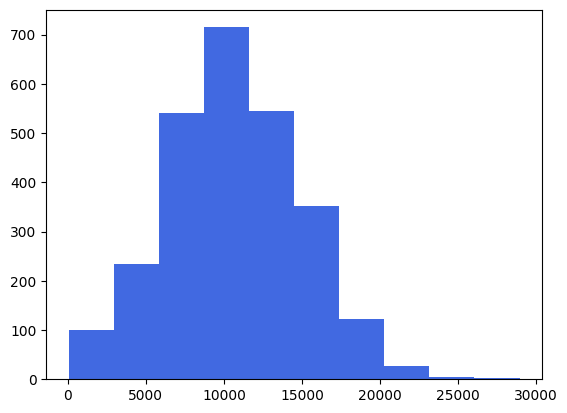

In [198]:
plt.hist(df["Production_Units"], color = "royalblue")

Max value: 25704
Min Value: 48
Mean Value: 9922.199621212121


<Axes: ylabel='Estimated_Deliveries'>

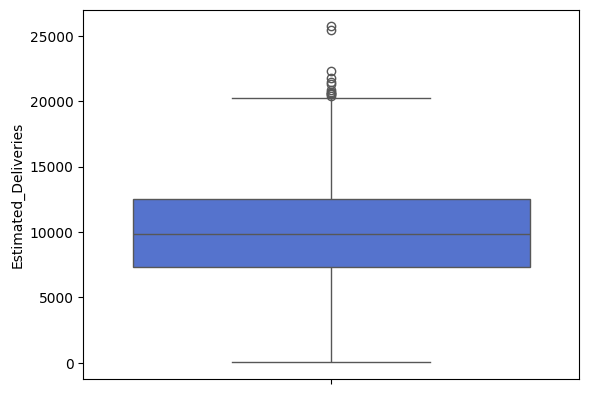

In [199]:
print("Max value:",df["Estimated_Deliveries"].max())
print("Min Value:",df["Estimated_Deliveries"].min())
print("Mean Value:",df["Estimated_Deliveries"].mean())
sns.boxplot(df["Estimated_Deliveries"], color = "royalblue")

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='Region'>

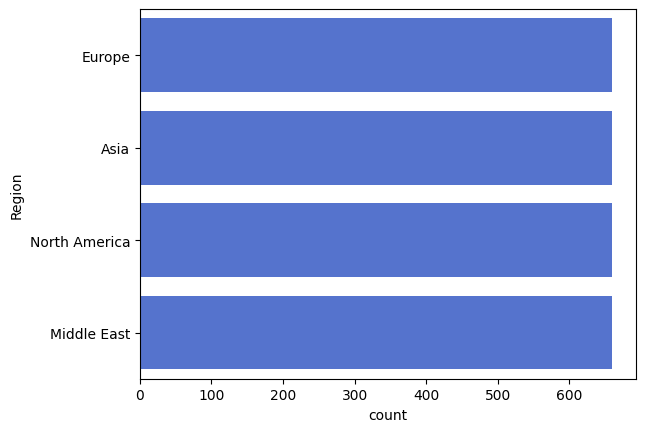

In [200]:
print(df["Region"].value_counts())
sns.countplot(df["Region"], color = "royalblue")

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='Model'>

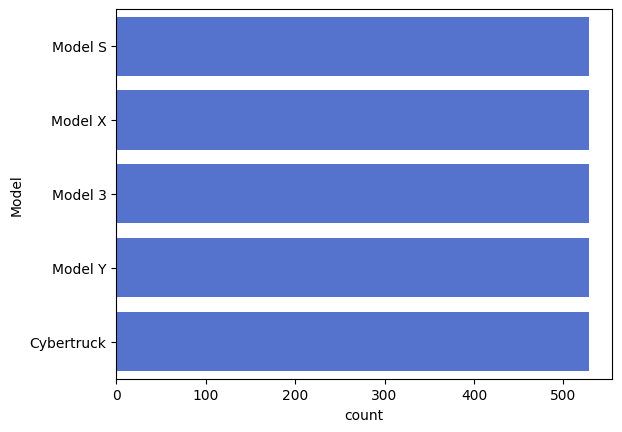

In [201]:
print(df["Model"].value_counts())
sns.countplot(df["Model"], color = "royalblue")

Bivariate/Multivariate EDA

*Deliveries by Vehicle Model*

Average Delivery per Model Model
Cybertruck     9677.611742
Model 3       10079.392045
Model S       10190.123106
Model X        9767.500000
Model Y        9896.371212
Name: Estimated_Deliveries, dtype: float64


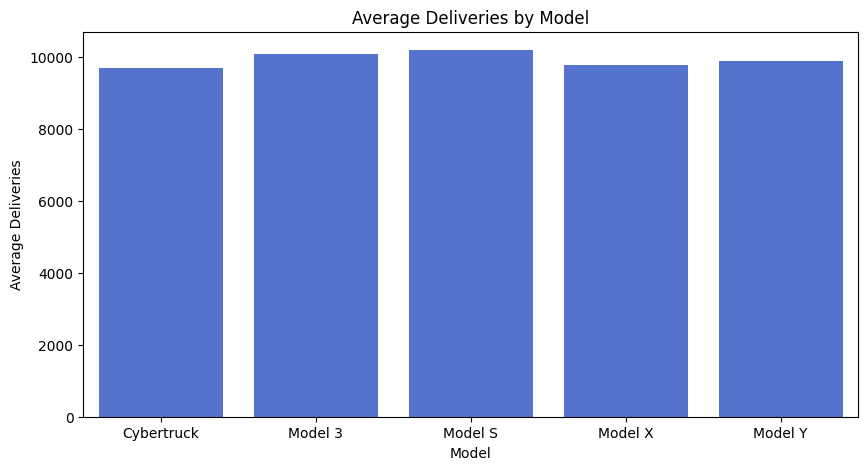

In [202]:
del_per_mod = (
    df.groupby("Model")["Estimated_Deliveries"].mean()
)
print("Average Delivery per Model",del_per_mod)

plt.figure(figsize = (10,5))

sns.barplot(
    x = del_per_mod.index,
    y = del_per_mod.values,
    color = "royalblue"
) 

plt.title("Average Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")
plt.show()

*Deliveries by Region*

Average delivery per Region Region
Asia              9908.992424
Europe            9839.446970
Middle East      10148.553030
North America     9791.806061
Name: Estimated_Deliveries, dtype: float64


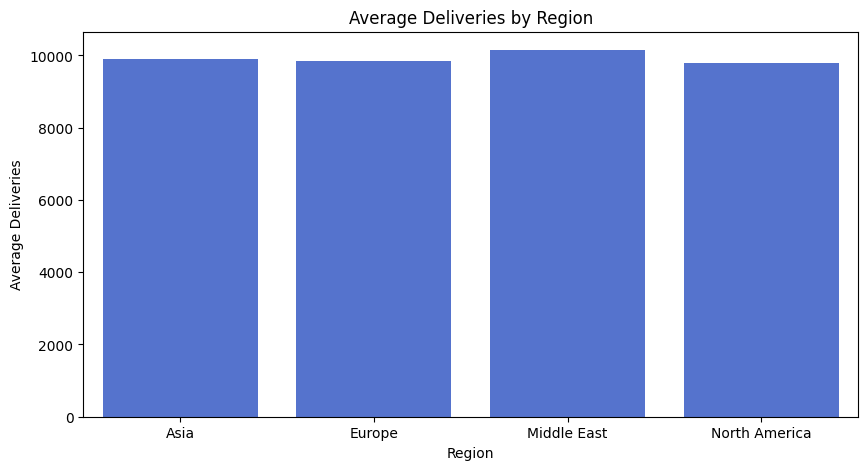

In [203]:
del_per_reg = (
    df.groupby("Region")["Estimated_Deliveries"].mean()
)
print("Average delivery per Region",del_per_reg)

plt.figure(figsize = (10,5))

sns.barplot(
    x = del_per_reg.index,
    y = del_per_reg.values,
    color = "royalblue"
)

plt.title("Average Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")
plt.show()

* Box Plot: Average Deliveries in every region for each Tesla model*

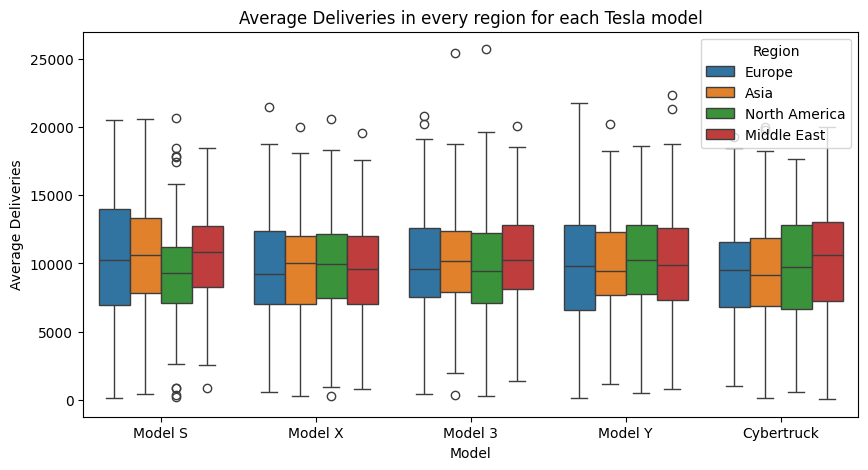

In [204]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Model"], 
    y=df["Estimated_Deliveries"],
    hue=df["Region"]
    )

plt.title("Average Deliveries in every region for each Tesla model")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")
plt.show()

* Bar Plot: Average Deliveries for each Tesla model in every region*

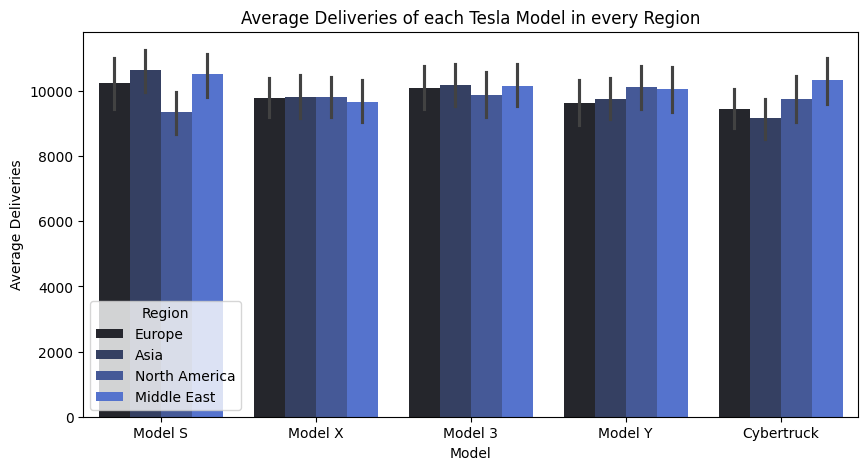

In [205]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=df["Model"],
    y=df["Estimated_Deliveries"],
    color = "royalblue",
    hue = df["Region"]
)

plt.title("Average Deliveries of each Tesla Model in every Region")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")
plt.show()

*Production vs Deliveries*

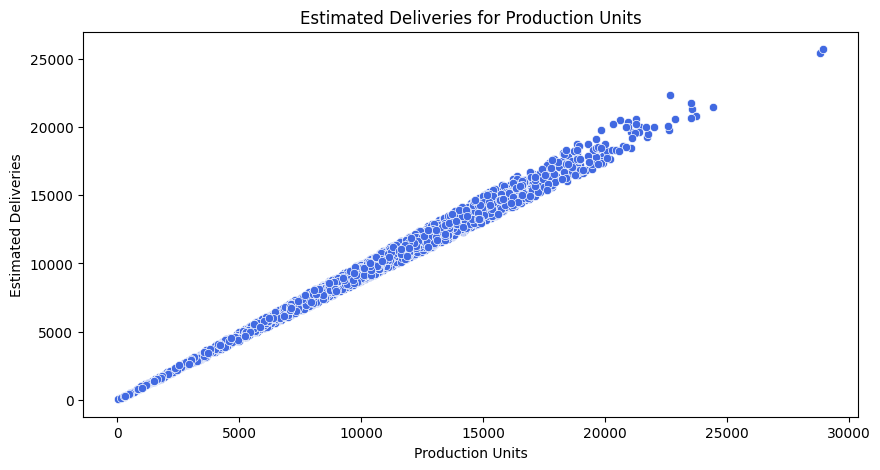

In [206]:
plt.figure(figsize = (10,5))

sns.scatterplot(
    x = df["Production_Units"],
    y = df["Estimated_Deliveries"],
    color = "royalblue"
)

plt.title("Estimated Deliveries for Production Units")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

*Tesla Deliveries Trend Over Time*

        Date  Estimated_Deliveries
0 2015-01-01                183180
1 2015-02-01                165053
2 2015-03-01                184567
3 2015-04-01                225623
4 2015-05-01                184264


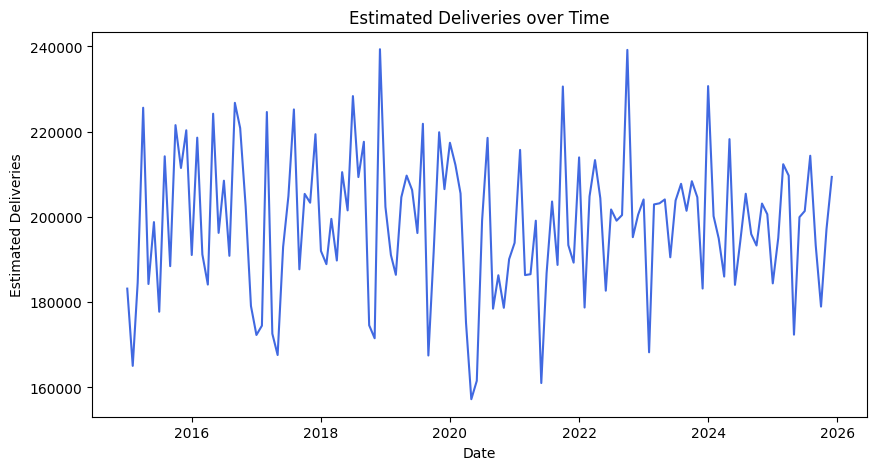

In [207]:
df["Year"] = df["Year"].astype(str)
df["Month"] = df["Month"].astype(str)
df["Date"] = df["Year"] + "-" + df["Month"]
df["Date"] = pd.to_datetime(df["Date"])

sales_by_date = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()
print(sales_by_date.head())

plt.figure(figsize = (10,5))

sns.lineplot(
    x = sales_by_date["Date"], 
    y = sales_by_date["Estimated_Deliveries"], 
    color = "royalblue"
    )

plt.title("Estimated Deliveries over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

## Feature Engineering

In this section Feature Engineering is done on the dataset so that it contribute efficiently on regression model.
- Encoding
- Lag Feature
- Rolling Mean

*Encoding: One Hot Encoding as Nominal Features are present in the data*

In [208]:
df_encoded = pd.get_dummies(
    df.copy(),
    columns = ["Model", "Region", "Source_Type"],
    drop_first = True
    )

*As all the columns are numerical now correlation between features is measured*

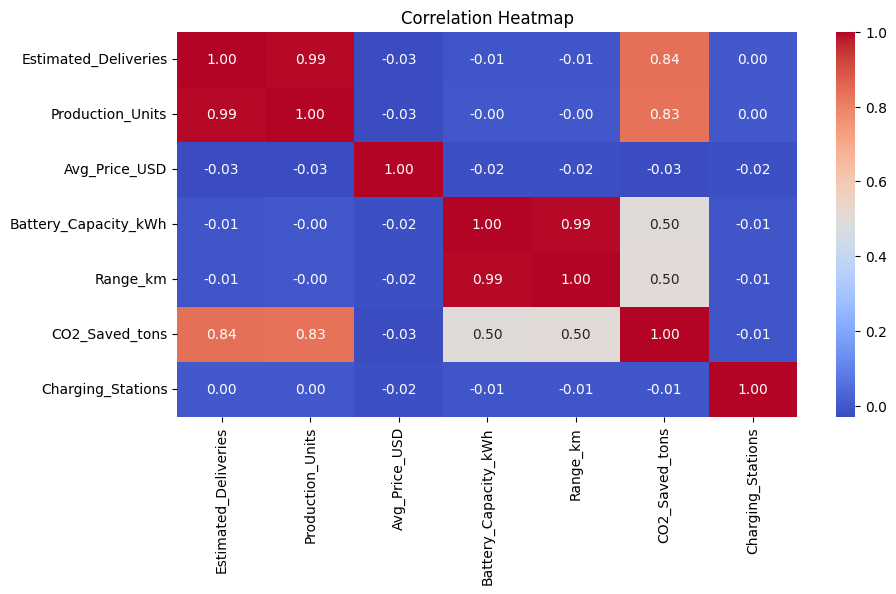

In [209]:
df_num = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,5))

sns.heatmap(
    df_num.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

*Lag Feature*

In [210]:
df_encoded = df_encoded.sort_values("Date")

df_encoded["Deliveries_Lag1"] = (
    df_encoded["Estimated_Deliveries"].shift(1)
)

df_encoded["Deliveries_Lag1"] = (
    df_encoded["Deliveries_Lag1"].fillna(
        df_encoded["Deliveries_Lag1"].mean()
    ))

*Rolling Mean*

In [211]:
df_encoded["Rolling_Mean_3"] = (
    df_encoded["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df_encoded["Rolling_Mean_3"] = df_encoded["Rolling_Mean_3"].fillna(
    df_encoded["Rolling_Mean_3"].mean()
)

In [212]:
# df_encoded.drop(columns = ["Rolling_Mean"], inplace = True)

In [213]:
df_encoded.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Model_Model S,Model_Model X,Model_Model Y,Region_Europe,Region_Middle East,Region_North America,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),Deliveries_Lag1,Rolling_Mean_3
872,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,...,False,False,True,False,False,False,False,True,9922.428192,9921.338261
2354,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,...,False,False,False,False,True,False,False,False,12446.000000,9921.338261
2312,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,...,False,False,False,False,True,False,True,False,11446.000000,10898.333333
2293,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,...,False,False,False,False,False,True,False,False,8803.000000,8872.000000
2215,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,...,False,False,False,False,False,False,False,True,6367.000000,7988.333333


## Regression Model Training

In this section Regression model is trained and it is used for predicting estimated deliveries of Tesla cars. Its performance is evaluated using evaluation metrics.

Chronological split is used to preserve time series nature of data.


*Splitting into dependent(y) and independent(X) variables*

In [214]:
X = df_encoded.drop(columns=["Estimated_Deliveries","Date"])
y = df_encoded["Estimated_Deliveries"]
print("Shape of X:",X.shape)
print("Shape of y;",y.shape)


Shape of X: (2640, 19)
Shape of y; (2640,)


*Train Test split*

In [215]:
split_index = int(len(df_encoded) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Length of X_train",len(X_train))
print("Length of X_test",len(X_test))

Length of X_train 2112
Length of X_test 528


In [216]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [217]:
y_pred = lr.predict(X_test)

*Evaluation of Linear Regression Model*

In [237]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.4f}")

Linear Regression Results
MAE : 322.43
MSE : 153453.13
RMSE : 391.73
R2 : 0.9885


*Visualising Actual and Predicted Values*

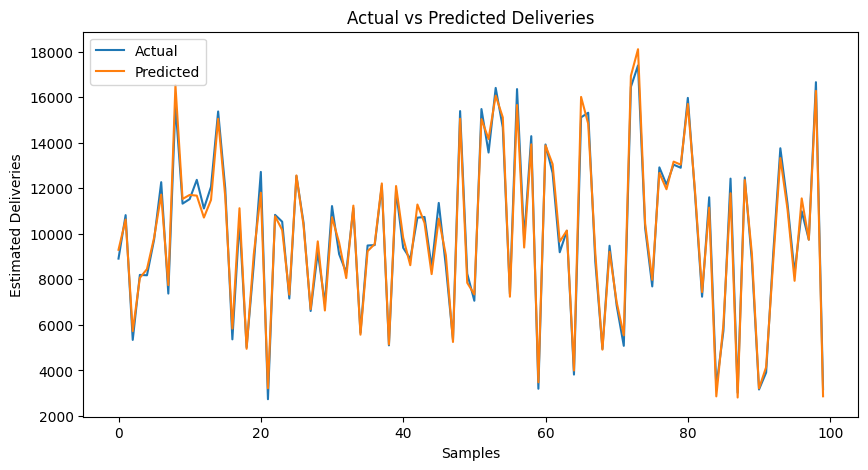

In [229]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label="Actual"
)
plt.plot(
    y_pred[:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Samples")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.show()

## Cross Validation

It helps to identify real performance of the model over k folds of the training and testing data.

In [230]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(lr,X,y,cv=kf,scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average R²:")
print(cv_scores.mean())

Cross Validation Scores:
[0.99031812 0.98959088 0.99062233 0.99086689 0.98975923]
Average R²:
0.9902314907630988


## Hyperparameter Tuning

hyperparameter are tuned for Random Forest Regressor to find optimal parameters for the model. GridSearchCV technique is used for tuning. 

In [231]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[25, 50, 100],
    "max_depth":[5, 10, None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}


## Random Forest Regressor

Random Forest Regressor Model is trained by using optimised features obtained from GridSearchCV.


In [234]:
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train, y_train)
rf_pred = best_rf.predict(X_test)

## Performance Evaluation

Evaluating performance of Random Forest Regressor

In [236]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.4f}")

Random Forest Results
MAE : 322.43
MSE : 153453.13
RMSE : 391.73
R2 : 0.9885


## Stationarity Test

Augmented Dickey-Fuller (ADF) Stationary test is used to check wether the time series data is stationary or not

In [239]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("P_Value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
P_Value: 0.0
Series is Stationary


## Target Forecasting

Using the Linear Regression Model Estimated Deliveries of Tesla Models are Forecasted


In [242]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

forecast_df

,Actual,Predicted
0,8910,9297.073079
1,10819,10626.640903
2,5341,5724.023910
3,8195,8064.892467
4,8179,8449.542093
5,9742,9827.788896
6,12266,11720.148913
7,7375,7746.743871
8,15680,16524.745905
9,11323,11529.104648


## Key Insights

* Production Units showed the strongest positive correlation with Estimated Deliveries, making it the most influential predictor in the dataset.

* Battery Capacity and Vehicle Range exhibited a very high correlation, indicating a strong relationship between battery size and driving range.

* Tesla delivery trends varied over time, revealing seasonal patterns and long-term changes in production and demand.

* The regression model achieved excellent predictive performance with a high R² (above 0.98) score and low prediction error metrics.

* Cross-validation and forecasting results demonstrated that the developed machine learning pipeline is robust and capable of generating reliable future delivery predictions.


## Conclusion

The project successfully implemented a complete end-to-end Machine Learning pipeline for Tesla delivery analysis and forecasting. Starting from raw data exploration and preprocessing, the workflow progressed through feature engineering, encoding, regression modeling, model evaluation, and time-series forecasting.

Exploratory Data Analysis revealed that production-related variables have the greatest influence on delivery volumes, while correlation analysis provided valuable insights into relationships among key features. Regression models achieved strong predictive performance, demonstrating their effectiveness in estimating Tesla deliveries based on operational and vehicle-related characteristics.

Cross-validation further validated the robustness of the developed models, while forecasting techniques enabled the prediction of future delivery trends using historical patterns. Overall, the project demonstrates how data-driven approaches can be used to analyze business performance, identify key drivers, and generate reliable predictions for strategic decision-making.